# A04 - Análisis de residuos

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 10/09/2026       |
| **Expediente** | 757806           |

Se regresa la tasa de graduacion contra los demas factores y se revisan los 6 problemas

La interaccion es Top10perc con Expend, que es la que sale significativa, todos los diagnosticos
salen de ese modelo

$$ \text{Grad.Rate} = \beta_0 + \beta_1(\text{factor}_1) + ... + \beta_k(\text{factor}_k) + \beta_{k+1}(\text{Top10perc} \times \text{Expend}) + \epsilon $$

In [29]:
# Cargar los datos de universidades

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

datos = pd.read_csv("College.csv")
datos = datos.rename(columns={"Unnamed: 0": "Universidad"})

print(datos.shape)
datos.head()

(777, 19)


,Universidad,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [30]:
# Private es texto así que se pasa a 1 y 0

datos["Private"] = (datos["Private"] == "Yes").astype(int)

datos["Private"].unique()

array([1, 0])

In [31]:
# Grad.Rate es la dependiente y todo lo demás son los factores

factores = [c for c in datos.columns if c not in ["Universidad", "Grad.Rate"]]

X_base = sm.add_constant(datos[factores])
y = datos["Grad.Rate"]

modelo_base = sm.OLS(y, X_base).fit()

print("Factores:", len(factores))
print("R2 sin interacción:", modelo_base.rsquared)

Factores: 17
R2 sin interacción: 0.46154054497464536


**Interacción entre factores**

In [32]:
#Top10perc por Expend
X = X_base.copy()
X["Top10perc x Expend"] = datos["Top10perc"] * datos["Expend"]

modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              Grad.Rate   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     36.87
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           8.31e-91
Time:                        20:46:49   Log-Likelihood:                -3067.2
No. Observations:                 777   AIC:                             6172.
Df Residuals:                     758   BIC:                             6261.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 37.9001      5

In [33]:
# Cuánto cambia el efecto del gasto según el nivel de los admitidos

b_expend = modelo.params["Expend"]
b_inter = modelo.params["Top10perc x Expend"]

for nivel in [10, 30, 50, 70]:
    efecto = b_expend + b_inter * nivel
    print("Con Top10perc =", nivel, "-> efecto de Expend:", round(efecto, 6))

Con Top10perc = 10 -> efecto de Expend: -0.001023
Con Top10perc = 30 -> efecto de Expend: -0.000792
Con Top10perc = 50 -> efecto de Expend: -0.000561
Con Top10perc = 70 -> efecto de Expend: -0.000329


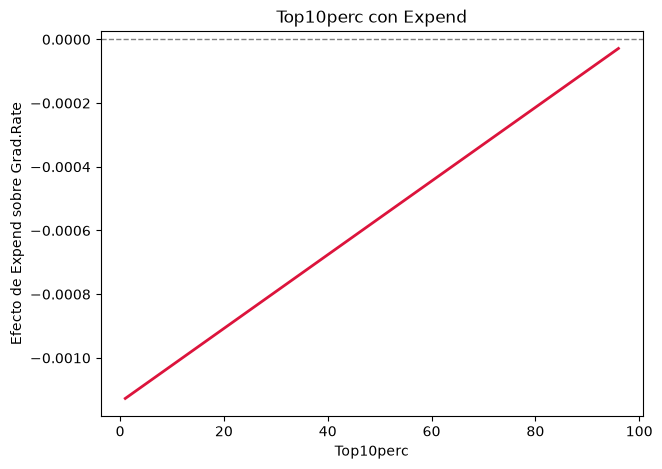

In [34]:
# El efecto del gasto según el nivel de los admitidos
niveles = np.linspace(datos["Top10perc"].min(), datos["Top10perc"].max(), 100)
efectos = b_expend + b_inter * niveles

cruce = -b_expend / b_inter

plt.figure(figsize=(7, 5))
plt.plot(niveles, efectos, color='crimson', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Top10perc')
plt.ylabel('Efecto de Expend sobre Grad.Rate')
plt.title('Top10perc con Expend')
plt.show()


La interaccion de Top10perc con Expend sale significativa con p = 0.0064

Expend solo sale negativo pero la interaccion positiva, o sea que mientras mas alto el Top10perc
menos negativo es el efecto de gastar

In [35]:
# Los residuos y los ajustados que se usan en todas las gráficas

ajustados = modelo.fittedvalues.values
residuos = modelo.resid.values

n = len(datos)
p = X.shape[1] - 1 # Los factores sin contar la constante

print("Observaciones:", n, " Factores:", p, " Parámetros:", p + 1)

Observaciones: 777  Factores: 18  Parámetros: 19


In [8]:
# Una función para sacar el promedio por tramos y ver la tendencia

def por_tramos(x, valores, tramos=10):
    orden = np.argsort(x)
    grupos_x = np.array_split(x[orden], tramos)
    grupos_v = np.array_split(valores[orden], tramos)

    centros = [np.mean(g) for g in grupos_x]
    promedios = [np.mean(g) for g in grupos_v]

    return centros, promedios

1. No linealidad de los datos

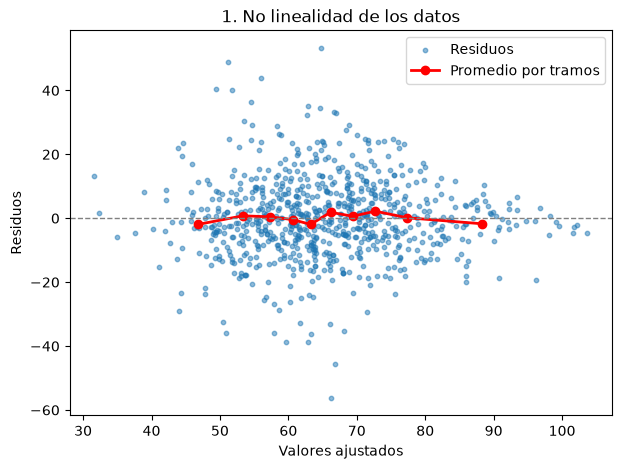

Promedio de residuos por tramo:
[-1.95  0.77  0.43 -0.42 -1.93  1.87  0.61  2.2   0.16 -1.73]


In [37]:
# Residuos contra ajustados con el promedio por tramos encima

centros, promedios = por_tramos(ajustados, residuos)

plt.figure(figsize=(7, 5))
plt.scatter(ajustados, residuos, s=10, alpha=0.5, label='Residuos')
plt.plot(centros, promedios, color='red', marker='o', linewidth=2, label='Promedio por tramos')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('1. No linealidad de los datos')
plt.legend()
plt.show()

print("Promedio de residuos por tramo:")
print(np.round(promedios, 2))

No se ve un problema ya que la línea roja no forma una curva, no hace la U que saldría si la relación fuera curva


**2. Correlación de los errores**

In [38]:
# Los residuos se ordenan por Grad.Rate

orden_y = np.argsort(y.values)
residuos_y = residuos[orden_y]

correlacion = np.corrcoef(residuos_y[:-1], residuos_y[1:])[0, 1]

print("Correlación entre un residuo (ordenado en y):", correlacion)

Correlación entre un residuo (ordenado en y): 0.4962807483083416


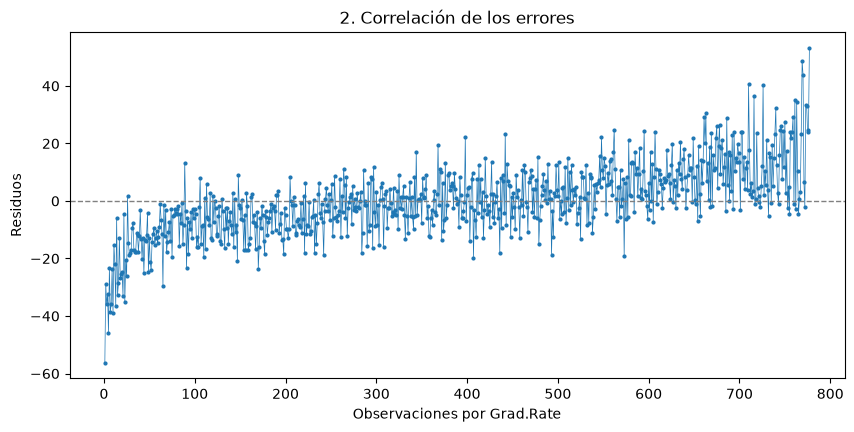

In [39]:
# Residuos ordenados de menor a mayor Grad.Rate

plt.figure(figsize=(10, 4.5))
plt.plot(range(1, n + 1), residuos_y, marker='o', markersize=2, linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Observaciones por Grad.Rate')
plt.ylabel('Residuos')
plt.title('2. Correlación de los errores')
plt.show()

Cuando se ordena por el grad rate si se ve un patron, se ven subiendo de negativos
a positivos, y la correlación con el residuo anterior da 0.496, aunque puede ser también por falta de info

**3. Varianza no constante en los errores**

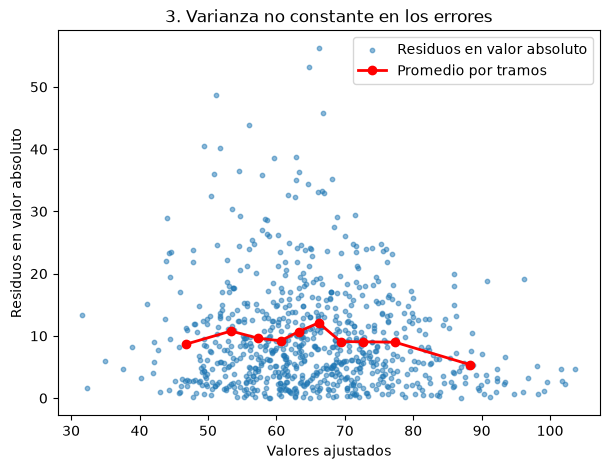

Residuo absoluto promedio por tramo:
[ 8.66 10.78  9.63  9.21 10.69 12.09  9.08  9.05  8.99  5.39]
Correlación entre ajustado y residuo absoluto: -0.11628255747801046


In [40]:
# Qué tan grandes son los residuos conforme crecen los ajustados

centros2, promedios2 = por_tramos(ajustados, np.abs(residuos))

plt.figure(figsize=(7, 5))
plt.scatter(ajustados, np.abs(residuos), s=10, alpha=0.5, label='Residuos en valor absoluto')
plt.plot(centros2, promedios2, color='red', marker='o', linewidth=2, label='Promedio por tramos')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos en valor absoluto')
plt.title('3. Varianza no constante en los errores')
plt.legend()
plt.show()

print("Residuo absoluto promedio por tramo:")
print(np.round(promedios2, 2))
print("Correlación entre ajustado y residuo absoluto:", np.corrcoef(ajustados, np.abs(residuos))[0, 1])

Aqui si hay problema ya que la línea roja se mantiene entre 8.7 y 12.1 casi todo el camino pero en el
último tramo se cae hasta 5.4, o sea que en las universidades con tasa de graduación predicha
más alta el modelo se equivoca  menos

**4. Valores atípicos**

In [41]:
# Residuos estandarizados

rss = np.sum(residuos ** 2)
rse = np.sqrt(rss / (n - p - 1))

estandarizados = residuos / rse

print("RSE:", rse)

RSE: 12.69131583348652


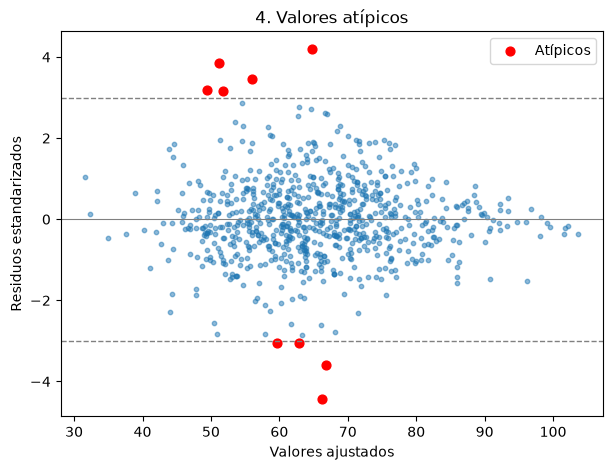

Cuántos atípicos: 9


In [42]:
# Los que se pasan de 3 desviaciones son los atípicos

atipicos = np.abs(estandarizados) > 3

plt.figure(figsize=(7, 5))
plt.scatter(ajustados[~atipicos], estandarizados[~atipicos], s=10, alpha=0.5)
plt.scatter(ajustados[atipicos], estandarizados[atipicos], s=40, color='red', label='Atípicos')
plt.axhline(3, color='gray', linestyle='--', linewidth=1)
plt.axhline(-3, color='gray', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos estandarizados')
plt.title('4. Valores atípicos')
plt.legend()
plt.show()

print("Cuántos atípicos:", atipicos.sum())

Sí hay problema, salieron 9 universidades que se pasan de las 3 desviaciones


**5. Puntos palanca**

In [43]:
# La palanca sale de la diagonal de la matriz 

Xv = X.values

sombrero = Xv @ np.linalg.inv(Xv.T @ Xv) @ Xv.T
palanca = np.diag(sombrero)

umbral = (p + 1) / n

print("Palanca promedio:", (p + 1) / n)
print("Umbral:", umbral)
print("Palanca más alta:", palanca.max())

Palanca promedio: 0.02445302445302445
Umbral: 0.02445302445302445
Palanca más alta: 0.459571938011609


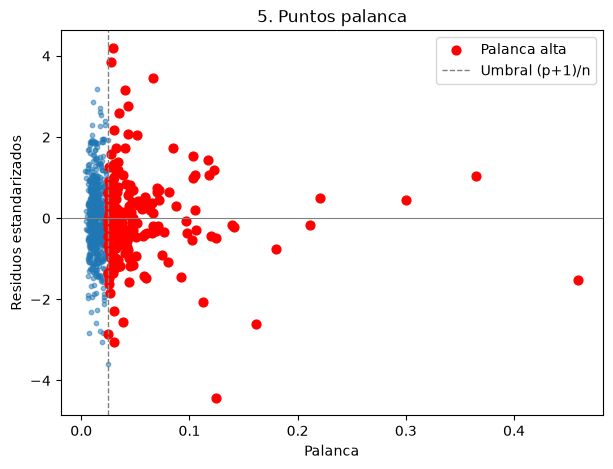

Cuántas pasan el umbral: 205


In [44]:
# Palanca contra residuos estandarizados

altos = palanca > umbral

plt.figure(figsize=(7, 5))
plt.scatter(palanca[~altos], estandarizados[~altos], s=10, alpha=0.5)
plt.scatter(palanca[altos], estandarizados[altos], s=40, color='red', label='Palanca alta')
plt.axvline(umbral, color='gray', linestyle='--', linewidth=1, label='Umbral (p+1)/n')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xlabel('Palanca')
plt.ylabel('Residuos estandarizados')
plt.title('5. Puntos palanca')
plt.legend()
plt.show()

print("Cuántas pasan el umbral:", altos.sum())

In [45]:
# Las cinco de palanca más alta

orden = np.argsort(palanca)[-5:]

tabla2 = datos.iloc[orden][["Universidad", "Apps", "Accept", "Enroll", "F.Undergrad", "Grad.Rate"]].copy()
tabla2["Palanca"] = np.round(palanca[orden], 4)

print(tabla2.to_string(index=False))

                        Universidad  Apps  Accept  Enroll  F.Undergrad  Grad.Rate  Palanca
        Center for Creative Studies   601     396     203          525         47   0.2110
           Johns Hopkins University  8474    3446     911         3566         90   0.2206
                 Antioch University   713     661     252          712         48   0.3004
University of Minnesota Twin Cities 11054    6397    3524        16502         45   0.3648
           Rutgers at New Brunswick 48094   26330    4520        21401         77   0.4596


Si hay problema, el umbral es la palanca promedio (p+1)/n = 0.024 y lo pasan 205

Las de hasta arriba son universidades enormes con muchas solicitudes y alumnos, muy lejos de las
demas, por eso jalan mas fuerte la regresion

**6. Colinealidad**

In [18]:
# El VIF se saca regresando cada factor contra todos los demás

columnas = [c for c in X.columns if c != "const"]

vifs = {}

for factor in columnas:
    otros = [f for f in columnas if f != factor]

    lr = LinearRegression()
    lr.fit(X[otros], X[factor])

    r2 = lr.score(X[otros], X[factor])
    vifs[factor] = 1 / (1 - r2)

vifs = pd.Series(vifs).sort_values(ascending=False)

print(vifs.round(2))

Accept                23.58
Enroll                22.37
F.Undergrad           17.96
Top10perc x Expend    17.67
Apps                  15.69
Top10perc             12.81
Expend                11.27
Top25perc              6.02
PhD                    4.05
Terminal               3.99
Outstate               3.85
Private                2.74
Room.Board             1.98
S.F.Ratio              1.96
perc.alumni            1.75
P.Undergrad            1.68
Personal               1.30
Books                  1.12
dtype: float64


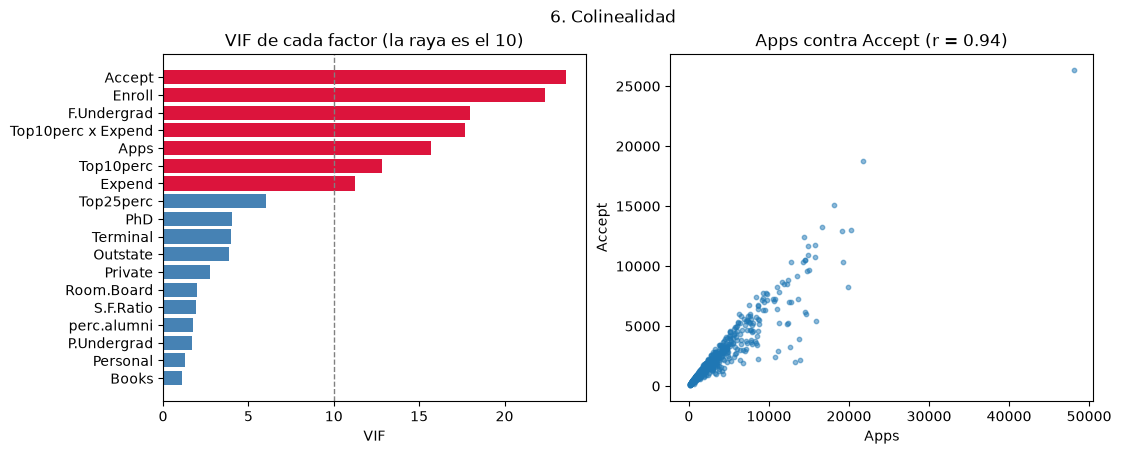

In [50]:
# Los VIF más altos y el par que los provoca

figura, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

colores = ['crimson' if v > 10 else 'steelblue' for v in vifs.values]
ejes[0].barh(range(len(vifs)), vifs.values, color=colores)
ejes[0].set_yticks(range(len(vifs)))
ejes[0].set_yticklabels(vifs.index)
ejes[0].axvline(10, color='gray', linestyle='--', linewidth=1)
ejes[0].invert_yaxis()
ejes[0].set_xlabel('VIF')
ejes[0].set_title('VIF de cada factor (la raya es el 10)')

ejes[1].scatter(datos['Apps'], datos['Accept'], s=10, alpha=0.5)
ejes[1].set_xlabel('Apps')
ejes[1].set_ylabel('Accept')
ejes[1].set_title('Apps contra Accept (r = %.2f)' % datos['Apps'].corr(datos['Accept']))

plt.suptitle('6. Colinealidad')
plt.show()

In [20]:
# Qué pasa si se quitan los tres factores más colineales

reducidos = [c for c in X.columns if c not in ["const", "Accept", "Enroll", "F.Undergrad"]]

X_red = sm.add_constant(X[reducidos])
modelo_red = sm.OLS(y, X_red).fit()

vif_max = 0
for factor in reducidos:
    otros = [f for f in reducidos if f != factor]
    r2 = LinearRegression().fit(X_red[otros], X_red[factor]).score(X_red[otros], X_red[factor])
    vif_max = max(vif_max, 1 / (1 - r2))

print("R2 con todos:    ", round(modelo.rsquared, 4))
print("R2 sin los tres: ", round(modelo_red.rsquared, 4))
print()
print("VIF más alto antes:  ", round(vifs.max(), 2))
print("VIF más alto después:", round(vif_max, 2))
print()
print("Error estándar de Apps antes:  ", round(modelo.bse["Apps"], 6))
print("Error estándar de Apps después:", round(modelo_red.bse["Apps"], 6))

R2 con todos:     0.4668
R2 sin los tres:  0.4662

VIF más alto antes:   23.66
VIF más alto después: 15.39

Error estándar de Apps antes:   0.000468
Error estándar de Apps después: 0.000162


Si hay problema y es el mas grave. Accept tiene VIF de 23.66, Enroll 22.37, F.Undergrad 18.29
y Apps 15.82, y arriba de 10 ya es serio

Es porque Apps son las solicitudes, Accept las aceptadas y Enroll las inscritas, o sea lo mismo
en tres etapas

Top10perc, Expend y la interaccion tambien salen altos pero eso es normal, la interaccion son
esos dos multiplicados

Quitando Accept, Enroll y F.Undergrad el R2 casi no baja, de 0.4668 a 0.4662, y el VIF mas alto
se cae de 23.66 a 15.39